# GWFish detector sensitivity and GW150914 strain

This notebook uses the repository LISA sensitivity helper plus `GWFish` detector PSD files/API to plot characteristic sensitivity curves for LISA, LGWA, and LIGO A+, then overlays an approximate GW150914 frequency-domain characteristic strain beginning 4 years before merger.

Conventions:
- Detector curves are plotted as characteristic noise, $h_n(f)=\sqrt{f S_n(f)}$.
- GW150914 is plotted as $h_c(f)=2 f |	ilde h(f)|$ using the GWFish `IMRPhenomD` waveform.
- The waveform starts at the leading-order inspiral frequency corresponding to 4 years before merger.


In [1]:
import os
from pathlib import Path

import matplotlib

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "code" and (cwd.parent / ".venv").exists() else cwd

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import importlib.util
import corner
import numpy as np
import matplotlib.pyplot as plt

import GWFish
from GWFish.modules import detection, ephemeris, fishermatrix, waveforms

module_path = PROJECT_ROOT / "code" / "test_notebook_functions.py"
spec = importlib.util.spec_from_file_location("test_notebook_functions", module_path)
tnf = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tnf)

import matplotlib
matplotlib.rcParams['text.usetex'] = True

%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({
    "figure.figsize": (9.0, 5.8),
    "font.size": 15,
    "axes.grid": True,
    "grid.linestyle": ":",
    "mathtext.fontset": "dejavuserif",
})

GWFISH_ROOT = Path(GWFish.__file__).resolve().parent
PSD_DIR = GWFISH_ROOT / "detector_psd"
OUTDIR = PROJECT_ROOT / "plots"
OUTDIR.mkdir(exist_ok=True)

YEAR = 365.25 * 24 * 3600
G = 6.67430e-11
C = 299792458.0
M_SUN = 1.98847e30

/home/ansonchen/.local/lib/python3.12/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Helper functions

In [2]:
def lisa_characteristic_noise_from_repo(fmin=1e-5, fmax=1.0, npoints=5000):
    """Return the LISA characteristic noise curve from test_notebook_functions.py."""
    f = np.geomspace(fmin, fmax, npoints)
    return f, tnf.lisa_characteristic_strain(f)

def taiji_characteristic_noise_from_repo(fmin=1e-5, fmax=1.0, npoints=5000):
    """Return the Taiji characteristic noise curve from test_notebook_functions.py."""
    f = np.geomspace(fmin, fmax, npoints)
    return f, tnf.taiji_characteristic_strain(f)

def tianqin_characteristic_noise_from_repo(fmin=2e-5, fmax=3.0, npoints=5000):
    """Return the TianQin characteristic noise curve from test_notebook_functions.py."""
    f = np.geomspace(fmin, fmax, npoints)
    return f, tnf.tianqin_characteristic_strain(f)

def amigo_characteristic_noise_from_repo(LAMIGO=1e7, fmin=1e-2, fmax=10.0, npoints=5000):
    """Return the AMIGO characteristic noise curve from test_notebook_functions.py."""
    f = np.geomspace(fmin, fmax, npoints)
    return f, tnf.amigo_characteristic_strain(f, LAMIGO=LAMIGO)

def DECIGO_characteristic_noise_from_repo(fmin=1e-3, fmax=100.0, npoints=5000):
    """Return the DECIGO characteristic noise curve from test_notebook_functions.py."""
    f = np.geomspace(fmin, fmax, npoints)
    return f, tnf.DECIGO_characteristic_strain(f)


def detector_characteristic_noise(detector_name):
    """Return f and sqrt(f S_n) from a GWFish detector component."""
    det = detection.Detector(detector_name)
    component = det.components[0]
    f = np.asarray(det.frequencyvector, dtype=float).squeeze()
    psd = np.asarray(component.Sn(f), dtype=float)
    return f, np.sqrt(f * psd)


def detector_characteristic_noise_sum(detector_name):
    """Return f and sqrt(f S_n,eff) using the summed inverse PSD across detector components."""
    det = detection.Detector(detector_name)
    f = np.asarray(det.frequencyvector, dtype=float).squeeze()
    inv_psd_sum = np.zeros_like(f, dtype=float)
    for component in det.components:
        psd = np.asarray(component.Sn(f), dtype=float)
        valid = np.isfinite(psd) & (psd > 0)
        inv_psd_sum[valid] += 1.0 / psd[valid]
    psd_eff = np.full_like(f, np.nan, dtype=float)
    valid = inv_psd_sum > 0
    psd_eff[valid] = 1.0 / inv_psd_sum[valid]
    return f, np.sqrt(f * psd_eff)


def psd_file_characteristic_noise(filename):
    """Return f and sqrt(f S_n) for two-column GWFish PSD files."""
    data = np.loadtxt(PSD_DIR / filename)
    f = data[:, 0]
    psd = data[:, 1]
    return f, np.sqrt(f * psd)


def component_masses_from_chirp_mass_q(chirp_mass, q):
    """Convert chirp mass and q=m2/m1<=1 to component masses."""
    m1 = chirp_mass * (1.0 + q) ** (1.0 / 5.0) / q ** (3.0 / 5.0)
    m2 = q * m1
    return m1, m2


def frequency_before_merger(t_before_merger, chirp_mass_detector_frame):
    """Leading-order observed GW frequency t seconds before coalescence."""
    mass_time = G * chirp_mass_detector_frame * M_SUN / C**3
    return (5.0 / (256.0 * t_before_merger)) ** (3.0 / 8.0) * mass_time ** (-5.0 / 8.0) / np.pi


def time_before_merger_from_frequency(frequency, chirp_mass_detector_frame):
    """Leading-order time to merger in seconds at observed GW frequency."""
    mass_time = G * chirp_mass_detector_frame * M_SUN / C**3
    return 5.0 / 256.0 * mass_time ** (-5.0 / 3.0) * (np.pi * frequency) ** (-8.0 / 3.0)


def format_duration(seconds):
    """Compact human-readable duration."""
    if seconds >= YEAR:
        return f"{seconds / YEAR:.2g} yr"
    if seconds >= 24 * 3600:
        return f"{seconds / (24 * 3600):.2g} d"
    if seconds >= 3600:
        return f"{seconds / 3600:.2g} hr"
    if seconds >= 60:
        return f"{seconds / 60:.2g} min"
    return f"{seconds:.2g} s"


m1_gw150914, m2_gw150914 = component_masses_from_chirp_mass_q(chirp_mass=28.1, q=29 / 36)

gw150914_params = {
    "mass_1": m1_gw150914,
    "mass_2": m2_gw150914,
    "luminosity_distance": 120.0,
    "redshift": 0.03,
    "theta_jn": 0.8,
    "phase": 1.5,
    "geocent_time": 0.0,
    "a_1": 0.1,
    "a_2": 0.1,
    # Sky-location and polarization angles are needed for GWFish detector projection.
    "ra": 1.5,
    "dec": 0.3,
    "psi": 0.5,
}


def gw150914_polarizations(f, param=gw150914_params):
    """Return GWFish IMRPhenomD plus/cross polarizations."""
    wf = waveforms.IMRPhenomD("IMRPhenomXPHM", param, {"frequencyvector": f})
    return wf.frequency_domain_strain


def gw150914_characteristic_strain(f):
    """Return h_c = 2 f sqrt(|h_+|^2 + |h_x|^2) for a GW150914-like source."""
    h_plus_cross = gw150914_polarizations(f)
    h_abs = np.sqrt(np.sum(np.abs(h_plus_cross) ** 2, axis=1))
    return 2.0 * f * h_abs


def gw150914_snr_polarizations(f, param=gw150914_params):
    """Return GWFish TaylorF2 plus/cross polarizations for detector-band SNRs."""
    wf = waveforms.TaylorF2("TaylorF2", param, {"frequencyvector": f})
    return wf.frequency_domain_strain


class BuiltinMoonEphemeris(ephemeris.MoonEphemeris):
    """Moon ephemeris using Astropy's built-in backend to avoid network downloads."""
    def get_icrs_from_times(self, times):
        from astropy.coordinates import get_body_barycentric
        from astropy.time import Time
        return get_body_barycentric("moon", Time(times, format="gps"), ephemeris="builtin")


def snr_with_gwfish(detector_name, param, frequencyvector=None, config=None):
    """Compute projected component and network SNR with GWFish."""
    detector = detection.Detector(detector_name, config=config) if config is not None else detection.Detector(detector_name)
    if detector.location == "moon":
        for component in detector.components:
            component.ephem = BuiltinMoonEphemeris()
    f = np.asarray(detector.frequencyvector if frequencyvector is None else frequencyvector, dtype=float).squeeze()
    polarizations = gw150914_snr_polarizations(f, param)
    timevector = waveforms.t_of_f_PN(param, f)
    signal = detection.projection(param, detector, polarizations, timevector)
    component_snrs = detection.SNR(detector, signal, frequencyvector=f)
    network_snr = np.sqrt(np.sum(component_snrs**2))
    return component_snrs, network_snr


f_start_4yr = frequency_before_merger(4.0 * YEAR, chirp_mass_detector_frame=28.1)
f_start_4yr


def lisa_tdi_characteristic_noises(fmin=1e-5, fmax=1.0, npoints=5000):
    """Return per-component LISA characteristic noise curves from GWFish."""
    det = detection.Detector("LISA")
    f = np.geomspace(fmin, fmax, npoints)
    curves = {}
    labels = ["A", "E", "T"]
    for idx, component in enumerate(det.components):
        psd = np.asarray(component.Sn(f), dtype=float)
        label = labels[idx] if idx < len(labels) else f"comp{idx}"
        curves[label] = (f, psd)
    return curves



def lisa_raw_acc_oms_noises():
    """Return raw ACC and OMS curves directly from GWFish LISA_psd.txt."""
    data = np.loadtxt(PSD_DIR / "LISA_psd.txt")
    f = data[:, 0]
    curves = {
        "ACC raw": (f, data[:, 1]),
        "OMS raw": (f, data[:, 2]),
    }
    return curves



def lisa_geometric_antenna_patterns(ra=1.5, dec=0.3, psi=0.5, n_time=2000):
    """Return low-frequency geometric LISA antenna patterns over one year."""
    theta = 0.5 * np.pi - dec
    phi = ra
    times = np.linspace(0.0, YEAR, n_time)
    alpha = 2.0 * np.pi * times / YEAR
    lambd = phi - alpha

    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    cos_2l = np.cos(2.0 * lambd)
    sin_2l = np.sin(2.0 * lambd)
    cos_2psi = np.cos(2.0 * psi)
    sin_2psi = np.sin(2.0 * psi)

    d_plus = (
        (np.sqrt(3.0) / 64.0)
        * ( -36.0 * sin_theta**2 * sin_2l
            + (3.0 + np.cos(2.0 * theta)) * (np.cos(2.0 * phi) * (9.0 * np.sin(2.0 * alpha) - np.sin(4.0 * alpha))
                                               + np.sin(2.0 * phi) * (np.cos(4.0 * alpha) - 9.0 * np.cos(2.0 * alpha)))
            - 4.0 * np.sqrt(3.0) * np.sin(2.0 * theta) * (np.sin(3.0 * alpha - 2.0 * phi) - 3.0 * np.sin(alpha - 2.0 * phi))
        )
    )

    d_cross = (
        (1.0 / 16.0)
        * ( np.sqrt(3.0) * cos_theta * (9.0 * np.cos(2.0 * phi - 2.0 * alpha) - np.cos(2.0 * phi - 4.0 * alpha))
            - 6.0 * sin_theta * (np.cos(phi - 3.0 * alpha) + 3.0 * np.cos(phi - alpha))
        )
    )

    f_plus = d_plus * cos_2psi - d_cross * sin_2psi
    f_cross = d_plus * sin_2psi + d_cross * cos_2psi
    return times / YEAR, f_plus, f_cross


## Build curves

`test_notebook_functions.py` provides the LISA characteristic-strain curve used here. `GWFish` includes a named detector for LGWA, and its package ships an `AplusDesign_psd.txt` file for LIGO A+.

In [14]:
curves = {}
curves["LISA"] = lisa_characteristic_noise_from_repo()
curves["Taiji"] = taiji_characteristic_noise_from_repo()
curves["TianQin"] = tianqin_characteristic_noise_from_repo()
# curves["LISA (GWFish)"] = detector_characteristic_noise_sum("LISA")
curves["LGWA"] = detector_characteristic_noise("LGWA")
curves["AMIGO"] = amigo_characteristic_noise_from_repo()
curves["AMIGO-5"] = amigo_characteristic_noise_from_repo(LAMIGO=5e7)
curves["DECIGO"] = DECIGO_characteristic_noise_from_repo()
curves["aLIGO A+"] = psd_file_characteristic_noise("AplusDesign_psd.txt")
curves["CE"] = psd_file_characteristic_noise("cosmic_explorer_strain_psd.txt")

lgwa_fmax = 3.0  # Plot LGWA only up to 3 Hz
lgwa_time_to_merger_sec = time_before_merger_from_frequency(lgwa_fmax, chirp_mass_detector_frame=28.1)
lgwa_time_to_merger_label = format_duration(lgwa_time_to_merger_sec)

# Use a dense log grid from the 4-year-before-merger frequency through the ground-band merger.
f_gw = np.geomspace(f_start_4yr, 1024.0, 6000)
hc_gw150914 = gw150914_characteristic_strain(f_gw)

print(f"GW150914-like m1={component_masses_from_chirp_mass_q(28.1, 29/36)[0]:.2f} Msun, "
      f"m2={component_masses_from_chirp_mass_q(28.1, 29/36)[1]:.2f} Msun")
print(f"Start frequency 4 years before merger: {f_start_4yr:.5f} Hz")
print(f"LGWA plotted upper frequency: {lgwa_fmax:.3g} Hz; GW150914 time to merger there: {lgwa_time_to_merger_label}")

GW150914-like m1=36.01 Msun, m2=29.00 Msun
Start frequency 4 years before merger: 0.01721 Hz
LGWA plotted upper frequency: 3 Hz; GW150914 time to merger there: 2.2 min


In [4]:
format_duration(time_before_merger_from_frequency(0.15, chirp_mass_detector_frame=28.1))


'4.5 d'

In [5]:
format_duration(time_before_merger_from_frequency(0.15, chirp_mass_detector_frame=1.4))


'1.8 yr'

In [6]:
format_duration(time_before_merger_from_frequency(0.02, chirp_mass_detector_frame=1.4))


'4e+02 yr'

## GWFish SNRs

The SNRs below use GWFish detector projection and `detection.SNR`. LISA, LGWA, LLO, LHO, LIGO India (`LIN`), Virgo, and KAGRA are all loaded directly from the built-in GWFish detector config. Note that the built-in `LLO`, `LHO`, and `LIN` entries use GWFish's default LIGO PSD file, not the local A+ override used previously.

In [7]:
gw150914_params = {
    "mass_1": m1_gw150914,
    "mass_2": m2_gw150914,
    "luminosity_distance": 410.0,
    "redshift": 0.1,
    "theta_jn": 0,
    "phase": 1.5,
    "geocent_time": 0.0,
    "a_1": 0.1,
    "a_2": 0.1,
    # Sky-location and polarization angles are needed for GWFish detector projection.
    "ra": 3,
    "dec": 0.,
    "psi": 0.,
}
snr_rows = []
for detector_label, detector_name, config in [
    ("LISA", "LISA", None),
    ("LGWA", "LGWA", None),
    ("LIGO LLO", "LLO", None),
    ("LIGO LHO", "LHO", None),
    ("LIGO India", "LIN", None),
    ("Virgo design", "VIR", None),
    ("KAGRA design", "KAG", None),
]:
    component_snrs, network_snr = snr_with_gwfish(detector_name, gw150914_params, config=config)
    snr_rows.append({
        "detector": detector_label,
        "component_SNRs": component_snrs,
        "network_SNR": network_snr,
    })

ligo_network_snr = np.sqrt(sum(row["network_SNR"] ** 2 for row in snr_rows if row["detector"].startswith("LIGO")))
lvk_network_snr = np.sqrt(sum(row["network_SNR"] ** 2 for row in snr_rows if row["detector"].startswith(("LIGO", "Virgo", "KAGRA"))))

snr_summary_rows = [
    {"detector": "LISA", "network_SNR": next(row["network_SNR"] for row in snr_rows if row["detector"] == "LISA")},
    {"detector": "LGWA", "network_SNR": next(row["network_SNR"] for row in snr_rows if row["detector"] == "LGWA")},
    {"detector": "LVK", "network_SNR": lvk_network_snr},
]

for row in snr_summary_rows:
    print(f"{row['detector']}: SNR = {row['network_SNR']:.2f}")

LISA: SNR = 3.86
LGWA: SNR = 57.80
LVK: SNR = 297.24


In [8]:
gw170917_params = {
    "mass_1": 1.4,
    "mass_2": 1.4,
    "luminosity_distance": 410.0,
    "redshift": 0.01,
    "theta_jn": 0,
    "phase": 1.5,
    "geocent_time": 0.0,
    "a_1": 0.1,
    "a_2": 0.1,
    # Sky-location and polarization angles are needed for GWFish detector projection.
    "ra": 3,
    "dec": 0.,
    "psi": 0.,
}
snr_rows = []
for detector_label, detector_name, config in [
    ("LISA", "LISA", None),
    ("LGWA", "LGWA", None),
    ("LIGO LLO", "LLO", None),
    ("LIGO LHO", "LHO", None),
    ("LIGO India", "LIN", None),
    ("Virgo design", "VIR", None),
    ("KAGRA design", "KAG", None),
]:
    component_snrs, network_snr = snr_with_gwfish(detector_name, gw170917_params, config=config)
    snr_rows.append({
        "detector": detector_label,
        "component_SNRs": component_snrs,
        "network_SNR": network_snr,
    })

ligo_network_snr = np.sqrt(sum(row["network_SNR"] ** 2 for row in snr_rows if row["detector"].startswith("LIGO")))
lvk_network_snr = np.sqrt(sum(row["network_SNR"] ** 2 for row in snr_rows if row["detector"].startswith(("LIGO", "Virgo", "KAGRA"))))

snr_summary_rows = [
    {"detector": "LISA", "network_SNR": next(row["network_SNR"] for row in snr_rows if row["detector"] == "LISA")},
    {"detector": "LGWA", "network_SNR": next(row["network_SNR"] for row in snr_rows if row["detector"] == "LGWA")},
    {"detector": "LVK", "network_SNR": lvk_network_snr},
]

for row in snr_summary_rows:
    print(f"{row['detector']}: SNR = {row['network_SNR']:.2f}")

LISA: SNR = 0.02
LGWA: SNR = 4.20
LVK: SNR = 22.85


In [9]:
amigo_characteristic_noise_from_repo()

(array([ 0.01      ,  0.01001383,  0.01002767, ...,  9.97240161,
         9.98619127, 10.        ]),
 array([2.26563553e-20, 2.26094445e-20, 2.25626308e-20, ...,
        6.00261117e-21, 6.01277579e-21, 6.02296221e-21]))

## Plot characteristic sensitivity and source strain

PosixPath('/home/ansonchen/multiband_cosmo/plots/gwfish_lisa_lgwa_aplus_gw150914_strain_2.png')

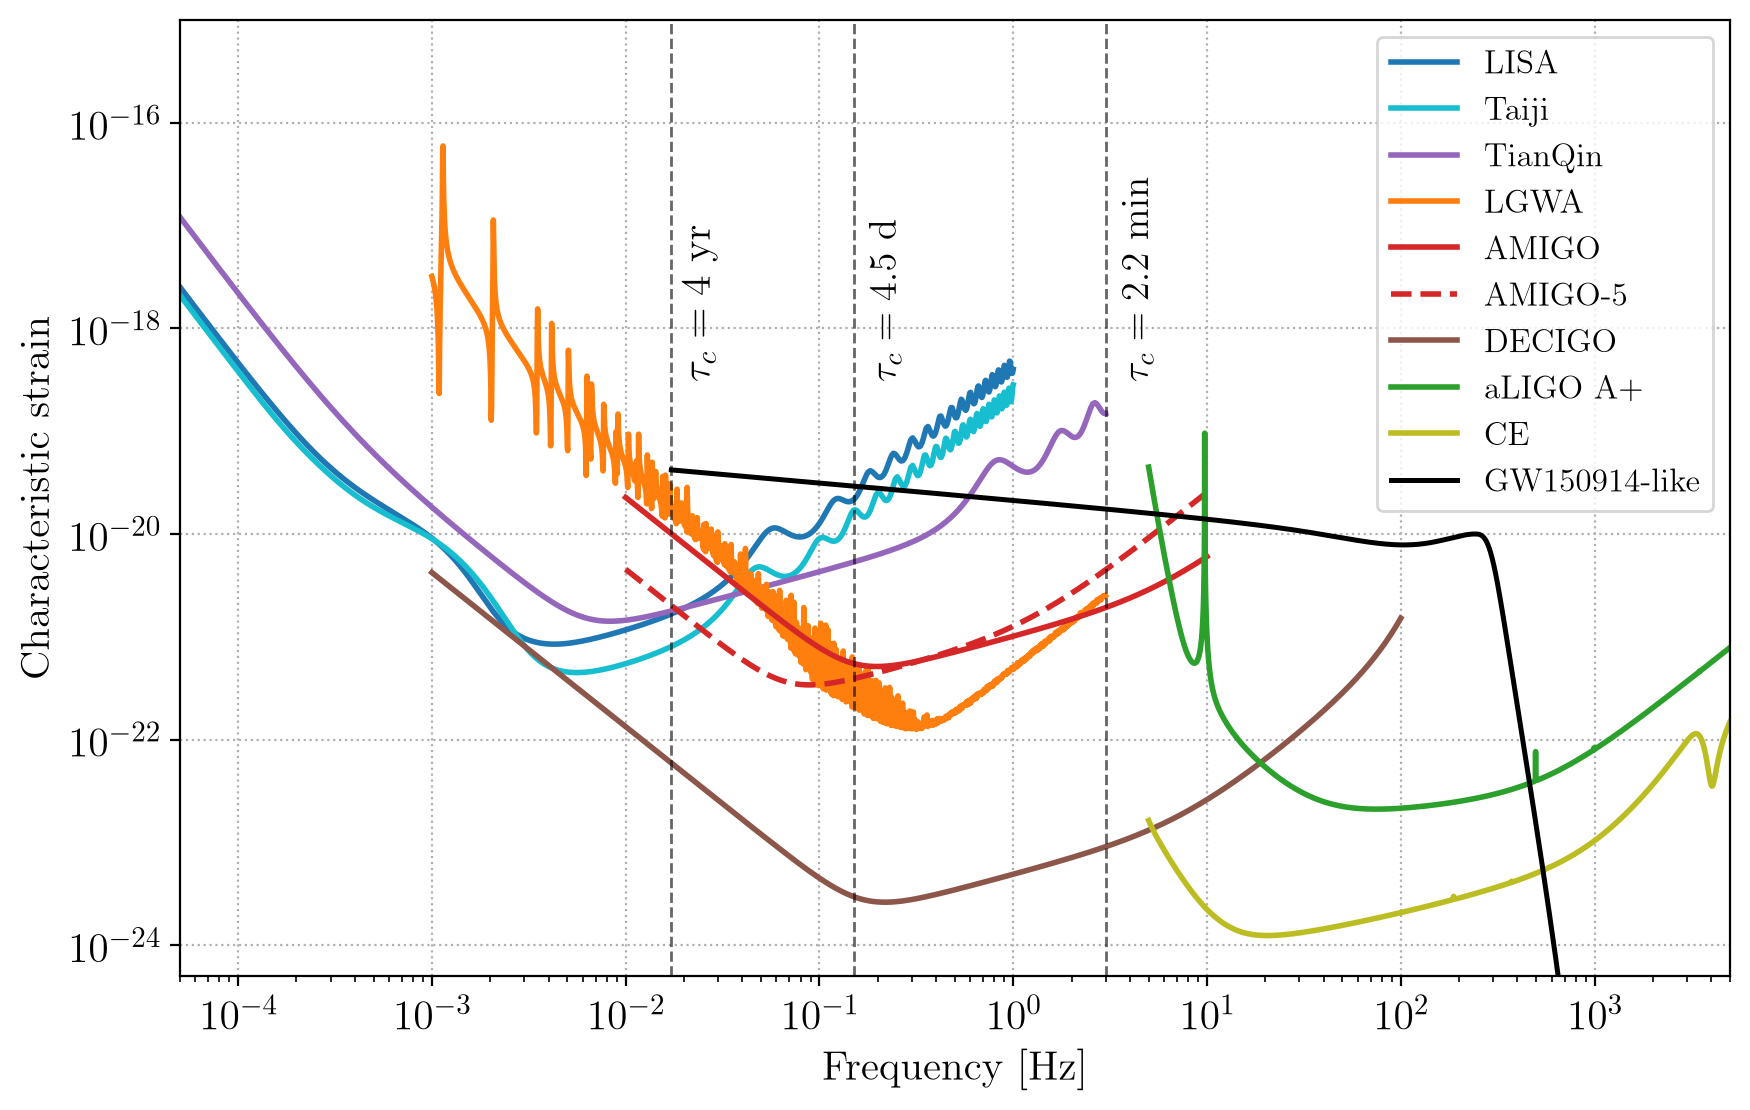

In [16]:
fig, ax = plt.subplots()

styles = {
    "LISA": {"color": "tab:blue", "lw": 2.0},
    "Taiji": {"color": "tab:cyan", "lw": 2.0},
    "TianQin": {"color": "tab:purple", "lw": 2.0},
    "LGWA": {"color": "tab:orange", "lw": 2.0},
    "AMIGO": {"color": "tab:red", "lw": 2.0},
    "AMIGO-5": {"color": "tab:red", "lw": 2.0, "linestyle": "--"},
    "DECIGO": {"color": "tab:brown", "lw": 2.0},
    "aLIGO A+": {"color": "tab:green", "lw": 2.0},
    "CE": {"color": "tab:olive", "lw": 2.0},
}

for label, (f, hn) in curves.items():
    mask = np.isfinite(f) & np.isfinite(hn) & (f > 0) & (hn > 0)
    if label == "LGWA":
        mask &= f <= lgwa_fmax
    ax.loglog(f[mask], hn[mask], label=label, **styles[label])

wave_mask = np.isfinite(hc_gw150914) & (hc_gw150914 > 0)
ax.loglog(f_gw[wave_mask], hc_gw150914[wave_mask], color="black", lw=1.8,
          label="GW150914-like")
ax.axvline(f_start_4yr, color="black", ls="--", lw=1.0, alpha=0.6)
ax.text(f_start_4yr * 1.12, 3e-19, r"$\tau_c = 4$ yr", rotation=90,
        va="bottom", ha="left", fontsize=15)

ax.axvline(0.15, color="k", ls="--", lw=1.0, alpha=0.6)
ax.text(0.15 * 1.2, 3e-19, r"$\tau_c = 4.5$ d",
        rotation=90, va="bottom", ha="left", fontsize=14)

ax.axvline(lgwa_fmax, color="k", ls="--", lw=1.0, alpha=0.6)
ax.text(lgwa_fmax * 1.2, 3e-19, r"$\tau_c = 2.2$ min",
        rotation=90, va="bottom", ha="left", fontsize=14)

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Characteristic strain")
ax.set_xlim(5e-5, 5e3)
ax.set_ylim(5e-25, 1e-15)
# snr_text = "\n".join(f"{row['detector']} SNR {row['network_SNR']:.1f}" for row in snr_summary_rows)
# ax.text(0.02, 0.03, snr_text, transform=ax.transAxes, va="bottom", ha="left", fontsize=12,
#         bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "0.8"})

ax.legend(loc="best",fontsize=12)
# ax.set_title("GWFish sensitivities and GW150914 characteristic strain")
fig.tight_layout()

output_path = OUTDIR / "gwfish_lisa_lgwa_aplus_gw150914_strain_2.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
output_path

In [23]:
data = np.loadtxt("R.txt")
f=np.geomspace(1e-3, 100.0, 5000)
x = f / ( 3e8 / (2 * np.pi * 1e8) )  # DECIGO arm length is 1000 km
log_response = np.interp(
    np.log10(x),
    np.log10(data[:, 0]),
    np.log10(data[:, 1]),
    left=np.log10(data[0, 1]),
    right=np.log10(data[-1, 1]),
)
response = 10**log_response
print(f,response)

[1.00000000e-03 1.00230570e-03 1.00461672e-03 ... 9.95404500e+01
 9.97699604e+01 1.00000000e+02] [1.50001752e-01 1.50001892e-01 1.50002032e-01 ... 3.07878600e-05
 3.07878600e-05 3.07878600e-05]


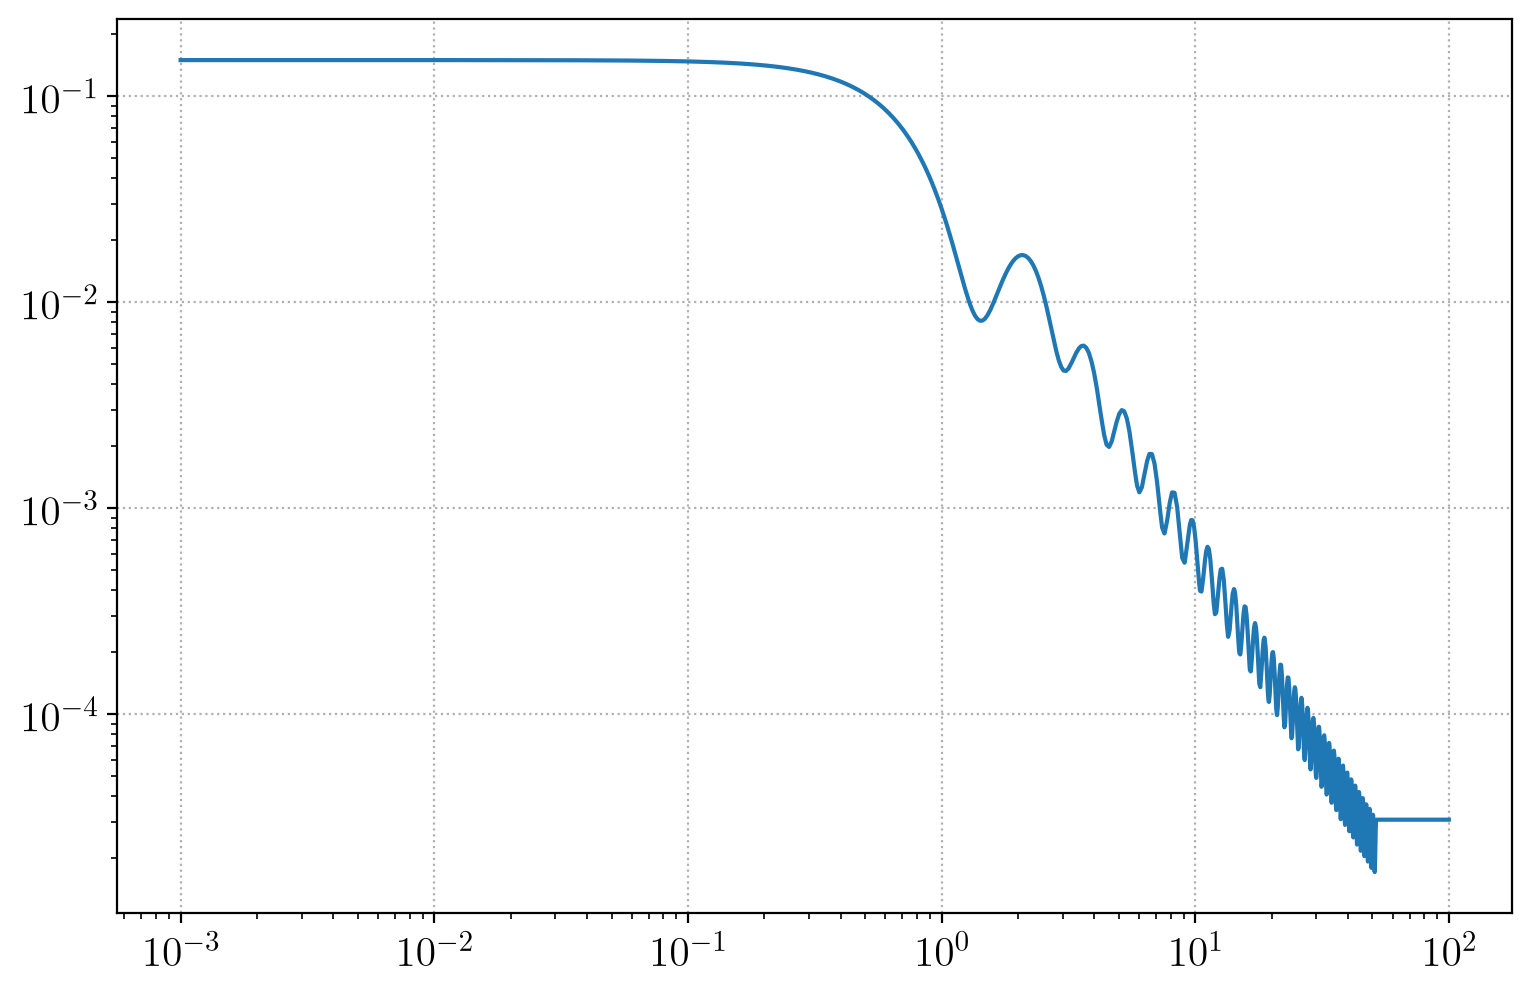

In [24]:
plt.loglog(f, response)

## LISA A/E/T projected strain for the GW150914-like event

Project the notebook event waveform into the GWFish LISA A/E/T channels and compare the channel strain amplitudes with the unprojected plus/cross strain amplitude.


PosixPath('/home/ansonchen/multiband_cosmo/plots/gwfish_lisa_aet_projected_strain_gw150914.png')

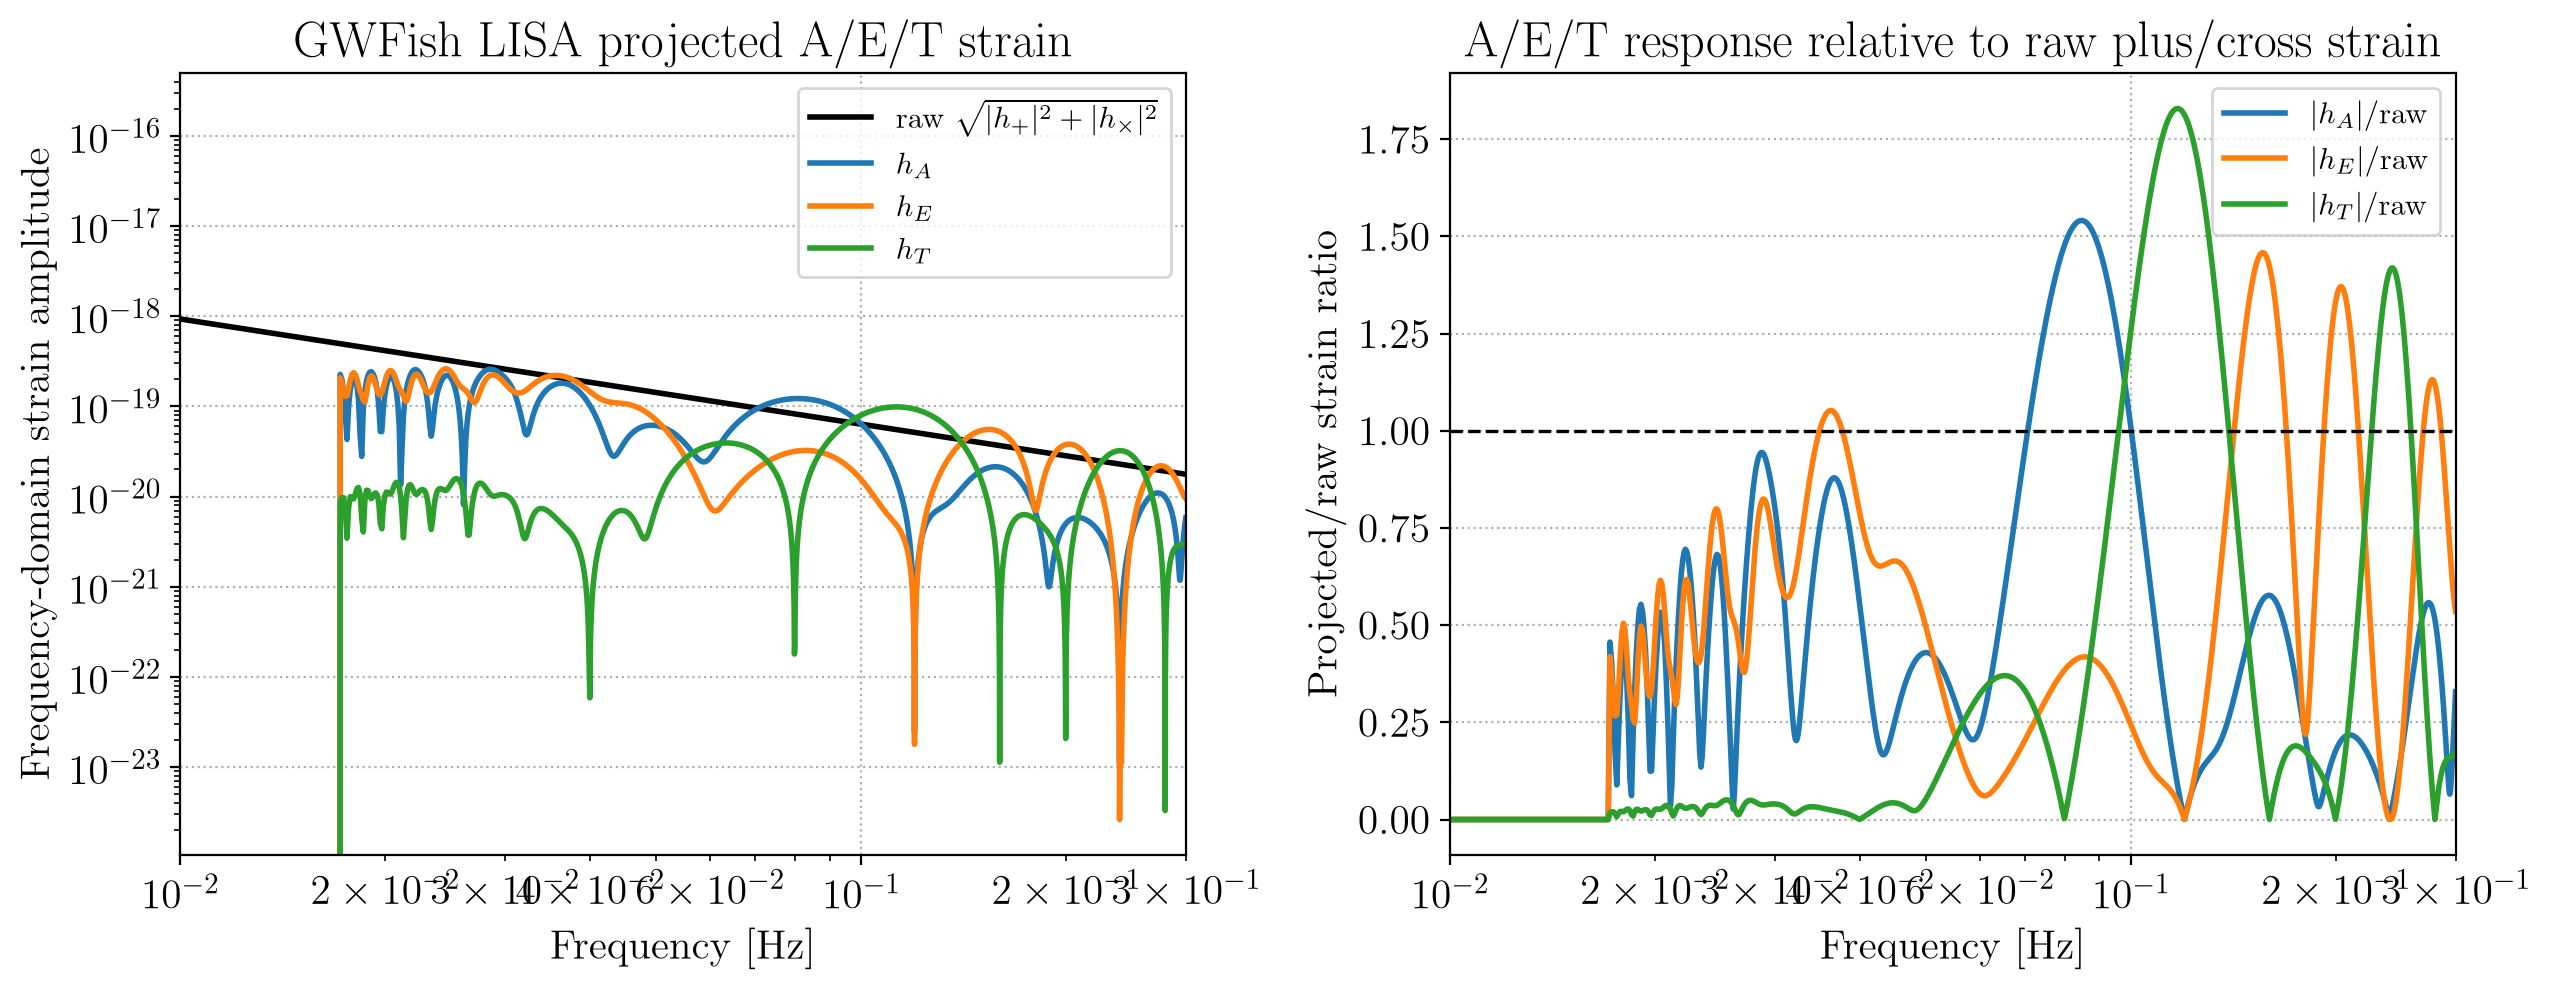

In [7]:
lisa_detector = detection.Detector("LISA")
f_lisa = np.asarray(lisa_detector.frequencyvector, dtype=float).squeeze()
polarizations_lisa = gw150914_snr_polarizations(f_lisa)
timevector_lisa = waveforms.t_of_f_PN(gw150914_params, f_lisa)
signal_aet = detection.projection(gw150914_params, lisa_detector, polarizations_lisa, timevector_lisa)

raw_strain = np.sqrt(np.sum(np.abs(polarizations_lisa) ** 2, axis=1))
aet_strain = {
    "A": np.abs(signal_aet[:, 0]),
    "E": np.abs(signal_aet[:, 1]),
    "T": np.abs(signal_aet[:, 2]),
}

fig_aet_strain, axes_aet_strain = plt.subplots(1, 2, figsize=(13.0, 5.2), sharex=True)

axes_aet_strain[0].loglog(f_lisa, raw_strain, color="black", lw=2.0, label=r"raw $\sqrt{|h_+|^2 + |h_\times|^2}$")
for label, strain in aet_strain.items():
    axes_aet_strain[0].loglog(f_lisa, strain, lw=2.0, label=fr"$h_{label}$")

for label, strain in aet_strain.items():
    axes_aet_strain[1].semilogx(f_lisa, strain / raw_strain, lw=2.0, label=fr"$|h_{label}|$/raw")
axes_aet_strain[1].axhline(1.0, color="black", lw=1.2, ls="--")

axes_aet_strain[0].set_ylabel(r"Frequency-domain strain amplitude")
axes_aet_strain[1].set_ylabel("Projected/raw strain ratio")
for ax in axes_aet_strain:
    ax.set_xlabel("Frequency [Hz]")
    ax.set_xlim(1e-2, f_lisa.max())
    ax.legend(loc="best", fontsize=11)

axes_aet_strain[0].set_title("GWFish LISA projected A/E/T strain")
axes_aet_strain[1].set_title("A/E/T response relative to raw plus/cross strain")
fig_aet_strain.tight_layout()

aet_strain_output_path = OUTDIR / "gwfish_lisa_aet_projected_strain_gw150914.png"
fig_aet_strain.savefig(aet_strain_output_path, dpi=200, bbox_inches="tight")
aet_strain_output_path


## Manual A/E/T scalar-product SNR check

Compute the LISA SNR directly from the projected A/E/T strains and the channel PSDs, then compare with `GWFish.modules.detection.SNR`.


In [8]:
channel_psd_on_lisa_grid = np.column_stack([
    np.asarray(component.Sn(f_lisa), dtype=float)
    for component in lisa_detector.components
])

manual_snr_squared_by_channel = 4.0 * np.trapz(
    np.abs(signal_aet) ** 2 / channel_psd_on_lisa_grid,
    f_lisa,
    axis=0,
)
manual_snr_by_channel = np.sqrt(manual_snr_squared_by_channel)
manual_network_snr = np.sqrt(np.sum(manual_snr_squared_by_channel))

gwfish_snr_by_channel = detection.SNR(lisa_detector, signal_aet, frequencyvector=f_lisa)
gwfish_network_snr = np.sqrt(np.sum(gwfish_snr_by_channel ** 2))

import pandas as pd
snr_comparison = pd.DataFrame({
    "channel": ["A", "E", "T", "network"],
    "manual_scalar_product_snr": [*manual_snr_by_channel, manual_network_snr],
    "gwfish_detection_snr": [*gwfish_snr_by_channel, gwfish_network_snr],
})
snr_comparison["absolute_difference"] = (
    snr_comparison["manual_scalar_product_snr"] - snr_comparison["gwfish_detection_snr"]
)
snr_comparison["fractional_difference"] = (
    snr_comparison["absolute_difference"] / snr_comparison["gwfish_detection_snr"]
)
snr_comparison


,channel,manual_scalar_product_snr,gwfish_detection_snr,absolute_difference,fractional_difference
0,A,2.580091,2.580091,-1.776357e-15,-6.884860e-16
1,E,2.801051,2.801051,-4.440892e-16,-1.585438e-16
2,T,0.613149,0.613149,2.220446e-16,3.621382e-16
3,network,3.857293,3.857293,-1.776357e-15,-4.605191e-16


## Averaged-response helper SNR comparison

Use the repository helper `tnf.snr_vs_merger_time`, which applies the averaged LISA response factor in its scalar-product SNR, and compare it with the GWFish projected A/E/T SNR for the same masses and distance.


In [9]:
helper_merger_time_yr = 4.0
_, helper_averaged_snr = tnf.snr_vs_merger_time(
    gw150914_params["mass_1"],
    gw150914_params["mass_2"],
    gw150914_params["luminosity_distance"],
    np.array([helper_merger_time_yr]),
    observation_years=4,
)
helper_averaged_snr = float(helper_averaged_snr[0])

snr_method_comparison = pd.DataFrame({
    "method": [
        "manual projected A/E/T scalar product",
        "GWFish detection.SNR on projected A/E/T",
        "tnf.snr_vs_merger_time averaged response",
    ],
    "SNR": [
        manual_network_snr,
        gwfish_network_snr,
        helper_averaged_snr,
    ],
})
snr_method_comparison["ratio_to_gwfish"] = snr_method_comparison["SNR"] / gwfish_network_snr
snr_method_comparison


,method,SNR,ratio_to_gwfish
0,manual projected A/E/T scalar product,3.857293,1.000000
1,GWFish detection.SNR on projected A/E/T,3.857293,1.000000
2,tnf.snr_vs_merger_time averaged response,4.653525,1.206423


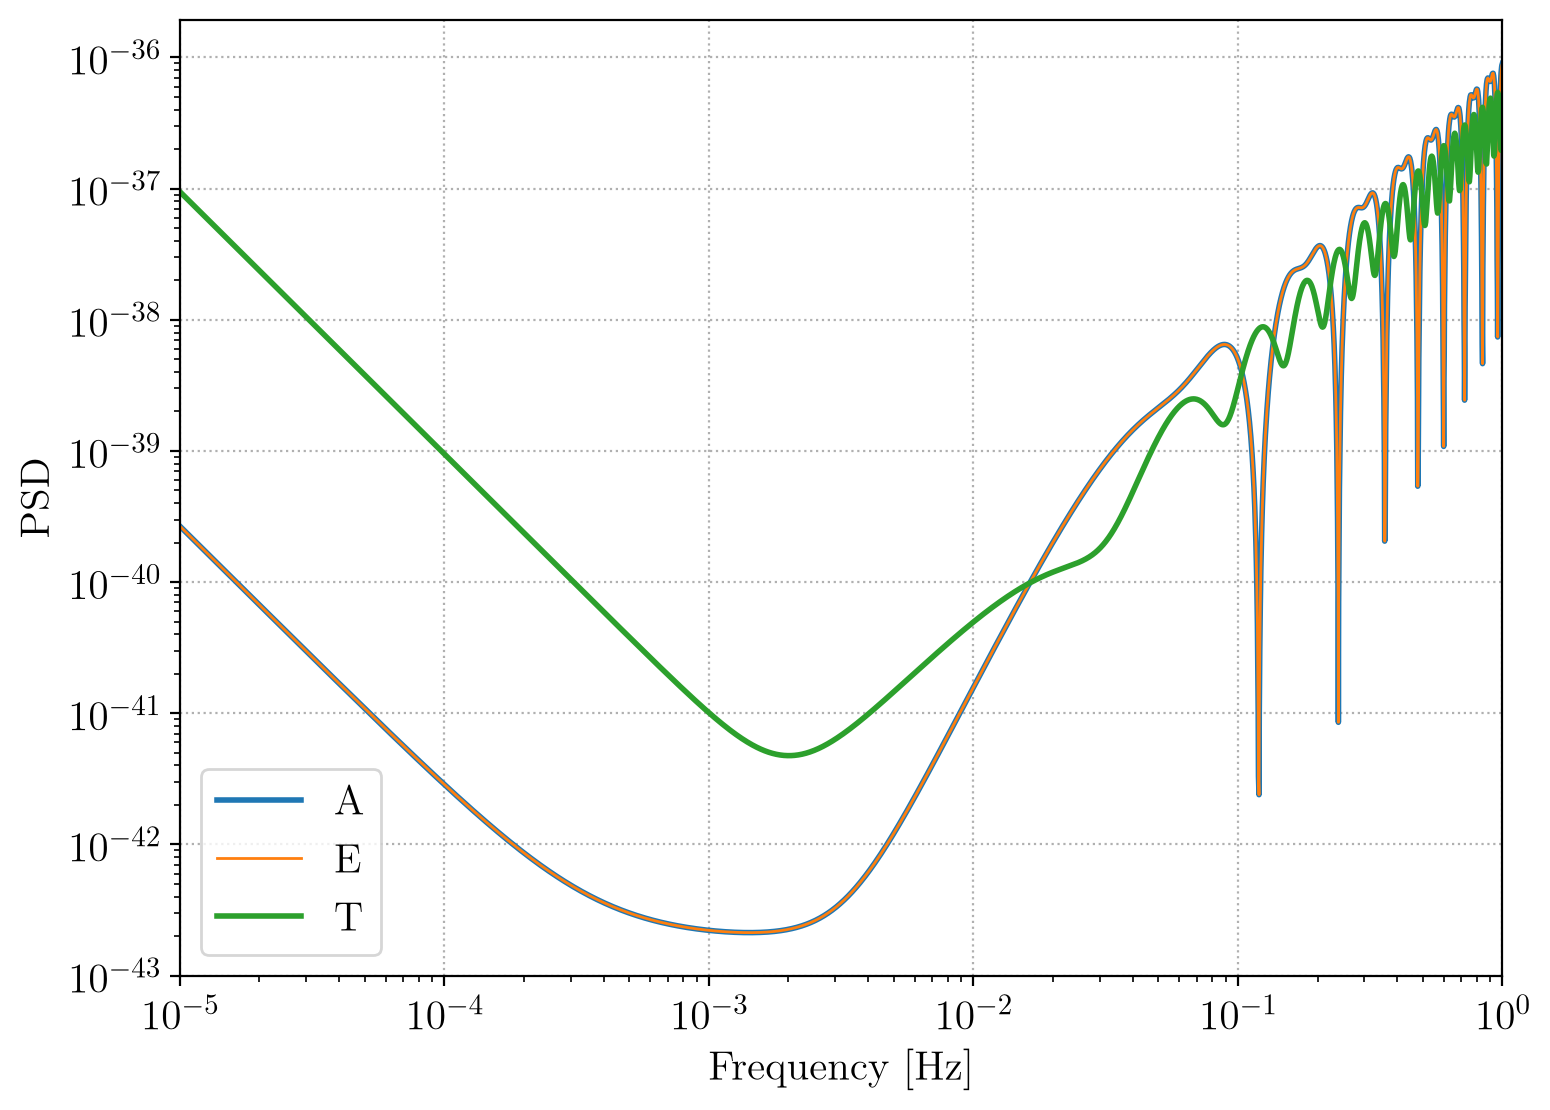

In [41]:
lisa_tdi_curves = lisa_tdi_characteristic_noises()
# lisa_tdi_curves["Combined"] = detector_characteristic_noise_sum("LISA")
fig_tdi, ax_tdi = plt.subplots()

tdi_styles = {
    "A": {"color": "tab:blue", "lw": 2.0},
    "E": {"color": "tab:orange", "lw": 1.0},
    "T": {"color": "tab:green", "lw": 2.0},
    # "Combined": {"color": "black", "lw": 2.2, "ls": "--"},
}

for label, (f, hn) in lisa_tdi_curves.items():
    mask = np.isfinite(f) & np.isfinite(hn) & (f > 0) & (hn > 0)
    ax_tdi.loglog(f[mask], hn[mask], label=label, **tdi_styles.get(label, {"lw": 2.0}))

ax_tdi.set_xlabel("Frequency [Hz]")
ax_tdi.set_ylabel(r"PSD")
ax_tdi.set_xlim(1e-5, 1.0)
# ax_tdi.set_ylim(1e-24, 1e-16)
ax_tdi.legend(loc="best")
fig_tdi.tight_layout()

# lisa_tdi_output_path = OUTDIR / "gwfish_lisa_aet_noise_curves.png"
# fig_tdi.savefig(lisa_tdi_output_path, dpi=200, bbox_inches="tight")
# lisa_tdi_output_path


## LISA A/E/T noise PSD versus raw GWFish PSD file

Compare the final GWFish A/E/T channel PSDs used by `detection.Detector("LISA")` against the raw proof-mass and optical-metrology Doppler-noise columns in `.venv/lib/python3.12/site-packages/GWFish/detector_psd/LISA_psd.txt`.


PosixPath('/home/ansonchen/multiband_cosmo/plots/gwfish_lisa_aet_vs_raw_psd.png')

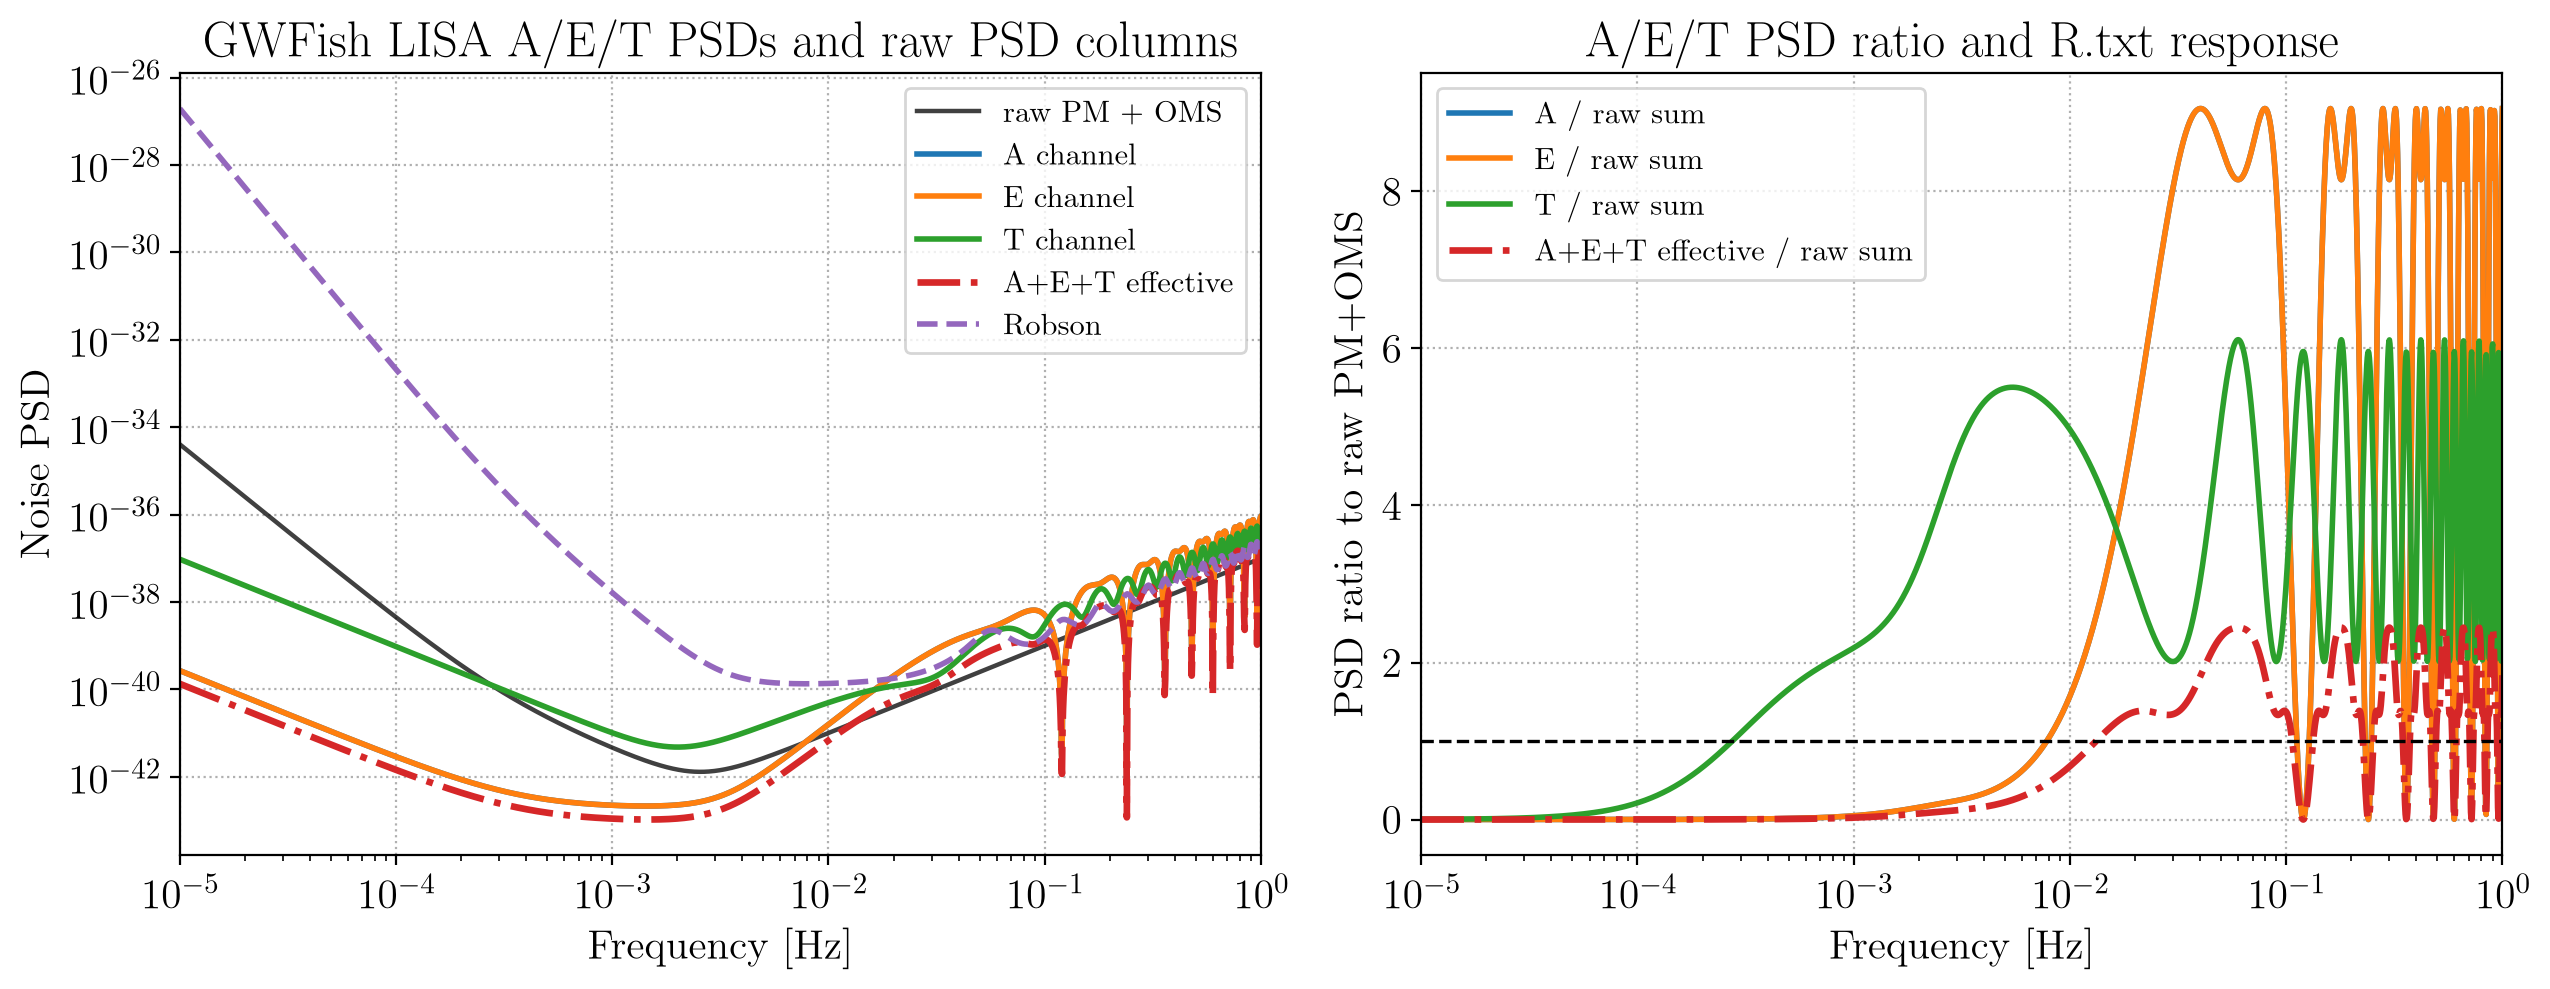

In [ ]:
lisa_psd_path = PROJECT_ROOT / ".venv" / "lib" / "python3.12" / "site-packages" / "GWFish" / "detector_psd" / "LISA_psd.txt"
raw_lisa_psd = np.loadtxt(lisa_psd_path)
f_raw = raw_lisa_psd[:, 0]
s_pm_raw = raw_lisa_psd[:, 1]
s_oms_raw = raw_lisa_psd[:, 2]
s_raw_sum = s_pm_raw + s_oms_raw

lisa_detector = detection.Detector("LISA")
channel_labels = ["A", "E", "T"]
channel_psds = {
    label: np.asarray(component.Sn(f_raw), dtype=float)
    for label, component in zip(channel_labels, lisa_detector.components)
}
inverse_aet_psd_sum = np.zeros_like(f_raw, dtype=float)
for psd in channel_psds.values():
    valid = np.isfinite(psd) & (psd > 0)
    inverse_aet_psd_sum[valid] += 1.0 / psd[valid]
s_aet_sum = np.full_like(f_raw, np.nan, dtype=float)
valid_sum = inverse_aet_psd_sum > 0
s_aet_sum[valid_sum] = 1.0 / inverse_aet_psd_sum[valid_sum]

fig_psd, axes_psd = plt.subplots(1, 2, figsize=(13.0, 5.2), sharex=True)

# axes_psd[0].loglog(f_raw, s_pm_raw, color="0.55", lw=1.8, ls="--", label="raw PM")
# axes_psd[0].loglog(f_raw, s_oms_raw, color="0.25", lw=1.8, ls=":", label="raw OMS")
axes_psd[0].loglog(f_raw, s_raw_sum, color="black", lw=1.6, alpha=0.75, label="raw PM + OMS")
for label, psd in channel_psds.items():
    axes_psd[0].loglog(f_raw, psd, lw=2.0, label=f"{label} channel")
axes_psd[0].loglog(f_raw, s_aet_sum, color="tab:red", lw=2.4, ls="-.", label="A+E+T effective")
axes_psd[0].loglog(f_raw, tnf.lisa_instrument_psd(f_raw), color="tab:purple", lw=2.0, ls="--", label="Robson")

for label, psd in channel_psds.items():
    axes_psd[1].semilogx(f_raw, psd / s_raw_sum, lw=2.0, label=f"{label} / raw sum")
axes_psd[1].semilogx(f_raw, s_aet_sum / s_raw_sum, color="tab:red", lw=2.4, ls="-.", label="A+E+T effective / raw sum")
axes_psd[1].axhline(1.0, color="black", lw=1.2, ls="--")

axes_psd[0].set_ylabel(r"Noise PSD")
axes_psd[1].set_ylabel(r"PSD ratio to raw PM+OMS")
for ax in axes_psd:
    ax.set_xlabel("Frequency [Hz]")
    ax.set_xlim(f_raw.min(), f_raw.max())
    ax.legend(loc="best", fontsize=11)

axes_psd[0].set_title("GWFish LISA A/E/T PSDs and raw PSD columns")
axes_psd[1].set_title("A/E/T PSD ratio and R.txt response")
fig_psd.tight_layout()

lisa_psd_comparison_path = OUTDIR / "gwfish_lisa_aet_vs_raw_psd.png"
fig_psd.savefig(lisa_psd_comparison_path, dpi=200, bbox_inches="tight")
lisa_psd_comparison_path


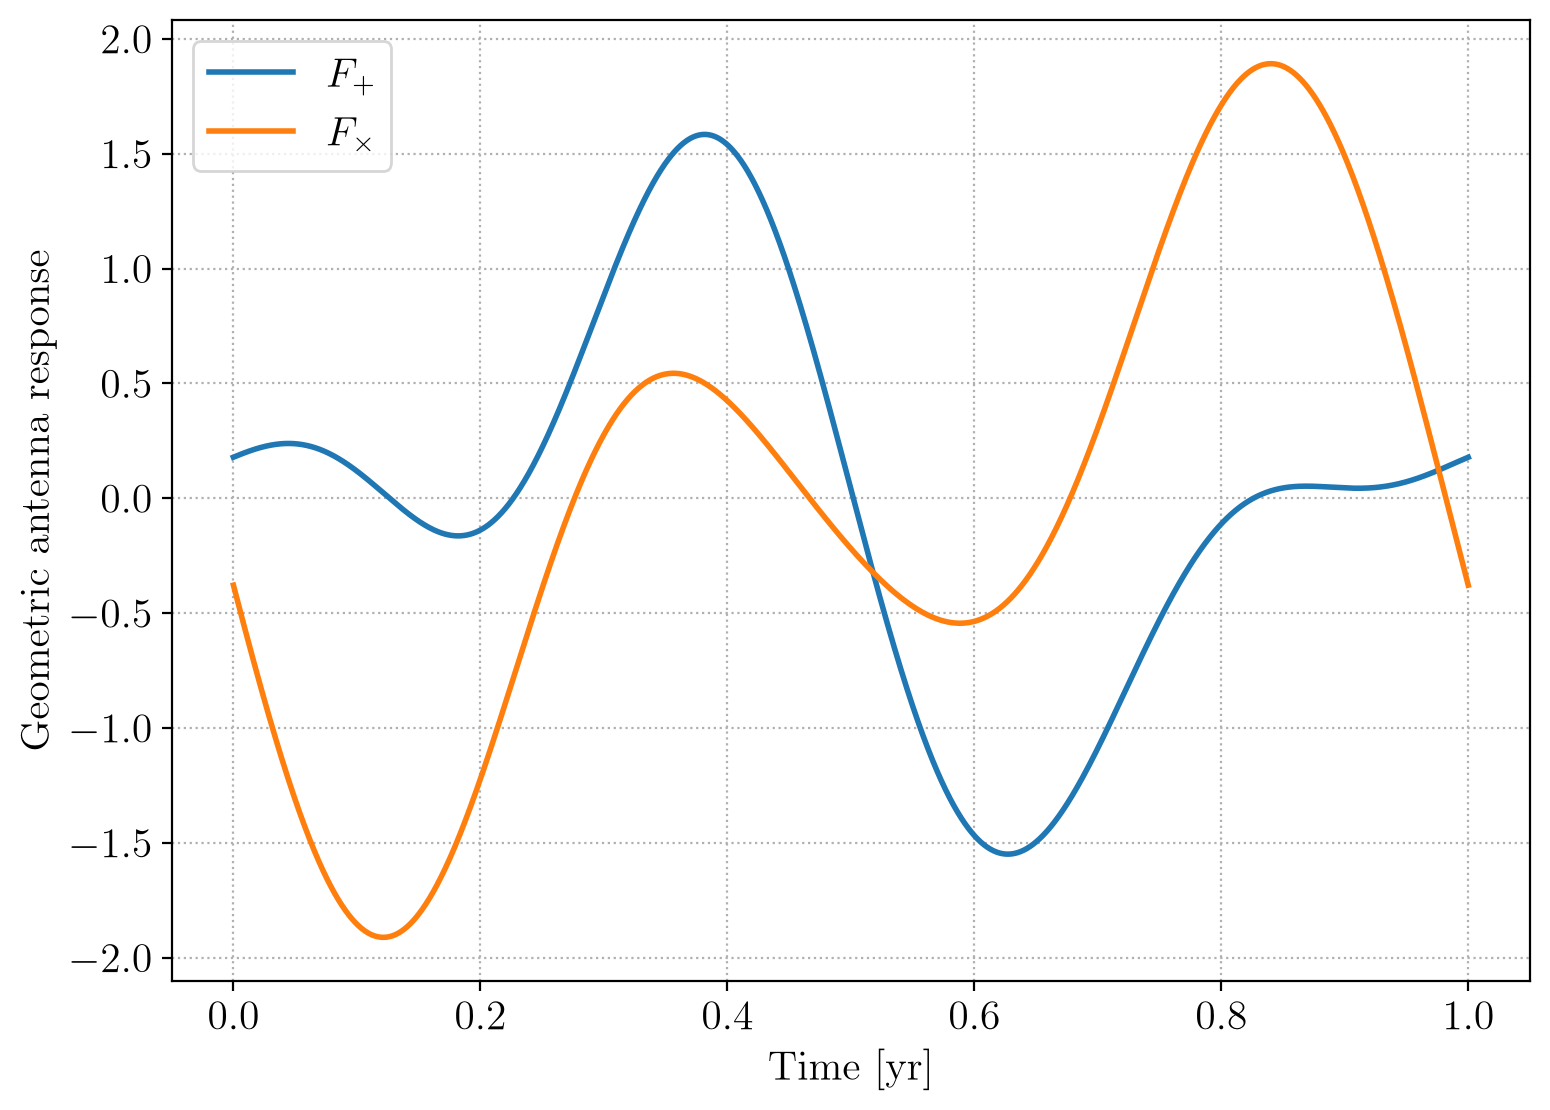

In [52]:
t_year, f_plus, f_cross = lisa_geometric_antenna_patterns()
fig_ant, ax_ant = plt.subplots()
ax_ant.plot(t_year, f_plus, label=r"$F_{+}$", color="tab:blue", lw=2.0)
ax_ant.plot(t_year, f_cross, label=r"$F_{\times}$", color="tab:orange", lw=2.0)
ax_ant.set_xlabel("Time [yr]")
ax_ant.set_ylabel("Geometric antenna response")
ax_ant.legend(loc="best")
ax_ant.grid(True, which="both", linestyle=":")
fig_ant.tight_layout()

# lisa_antenna_output_path = OUTDIR / "gwfish_lisa_geometric_antenna_patterns.png"
# fig_ant.savefig(lisa_antenna_output_path, dpi=200, bbox_inches="tight")
# lisa_antenna_output_path


## GWFish Fisher matrix and corner plot

This section computes Fisher matrices with GWFish for LISA, LGWA, the LVK ground network, and the combined network. It prints 1σ uncertainties from each inverse Fisher matrix and uses the `corner` package to draw Gaussian posterior corner plots. The waveform class is GWFish's LAL `IMRPhenomD`, so the spin derivatives `a_1` and `a_2` are included. The Fisher point is nudged to `theta_jn = 0.1 rad`; exactly face-on (`theta_jn = 0`) is singular for inclination/spin-amplitude derivatives.

This version also includes the sky-position and polarization response parameters `ra`, `dec`, and `psi` in the Fisher matrix.

In [7]:
FISHER_PARAMETERS = [
    "chirp_mass",
    "mass_ratio",
    "luminosity_distance",
    "theta_jn",
    "ra",
    "dec",
    "psi",
    "geocent_time",
    "phase",
    "a_1",
    "a_2",
]

fisher_params = dict(gw150914_params)
fisher_params.pop("mass_1")
fisher_params.pop("mass_2")
fisher_params["chirp_mass"] = 28.1
fisher_params["mass_ratio"] = 29 / 36
fisher_params["theta_jn"] = 0.8

FISHER_NETWORKS = {
    "LISA": [("LISA", "LISA")],
    "LGWA": [("LGWA", "LGWA")],
    "LVK": [
        ("LIGO LLO", "LLO"),
        ("LIGO LHO", "LHO"),
        ("LIGO India", "LIN"),
        ("Virgo design", "VIR"),
        ("KAGRA design", "KAG"),
    ],
}
FISHER_NETWORKS["Combined"] = FISHER_NETWORKS["LISA"] + FISHER_NETWORKS["LGWA"] + FISHER_NETWORKS["LVK"]


def detector_for_fisher(detector_name):
    detector = detection.Detector(detector_name)
    if detector.location == "moon":
        for component in detector.components:
            component.ephem = BuiltinMoonEphemeris()
    return detector


def compute_network_fisher_matrix(detector_specs, parameters, fisher_parameters):
    network_fisher = np.zeros((len(fisher_parameters), len(fisher_parameters)))
    detector_fisher_rows = []
    for detector_label, detector_name in detector_specs:
        detector = detector_for_fisher(detector_name)
        detector_fisher, detector_snr_square = fishermatrix.compute_detector_fisher(
            detector,
            parameters,
            fisher_parameters=fisher_parameters,
            waveform_model="IMRPhenomXPHM",
            waveform_class=waveforms.LALFD_Waveform,
            use_duty_cycle=False,
        )
        network_fisher += detector_fisher
        detector_fisher_rows.append({
            "detector": detector_label,
            "snr": np.sqrt(detector_snr_square),
            "fisher": detector_fisher,
        })
    covariance, singular_values = fishermatrix.invertSVD(network_fisher)
    if covariance is None:
        raise RuntimeError("Fisher matrix inversion failed; check parameter degeneracies or finite-difference steps.")
    covariance = 0.5 * (covariance + covariance.T)
    uncertainties = np.sqrt(np.clip(np.diag(covariance), 0.0, np.inf))
    network_snr = np.sqrt(sum(row["snr"] ** 2 for row in detector_fisher_rows))
    return {
        "fisher": network_fisher,
        "covariance": covariance,
        "uncertainties": uncertainties,
        "singular_values": singular_values,
        "detector_rows": detector_fisher_rows,
        "network_snr": network_snr,
    }


fisher_results = {
    name: compute_network_fisher_matrix(specs, fisher_params, FISHER_PARAMETERS)
    for name, specs in FISHER_NETWORKS.items()
}

fisher_mean = np.array([fisher_params[p] for p in FISHER_PARAMETERS], dtype=float)

for network_name, result in fisher_results.items():
    print(f"\n{network_name} Fisher result")
    print(f"  Network SNR: {result['network_snr']:.2f}")
    print("  Detector SNRs:")
    for row in result["detector_rows"]:
        print(f"    {row['detector']}: {row['snr']:.2f}")
    print("  1-sigma uncertainties:")
    for name, value, sigma in zip(FISHER_PARAMETERS, fisher_mean, result["uncertainties"]):
        rel = sigma / abs(value) if value != 0 else np.nan
        rel_text = f" ({100 * rel:.3g}%)" if np.isfinite(rel) else ""
        print(f"    {name:22s} = {value:.8g} +/- {sigma:.6g}{rel_text}")


LISA Fisher result
  Network SNR: 9.45
  Detector SNRs:
    LISA: 9.45
  1-sigma uncertainties:
    chirp_mass             = 28.1 +/- 8.80435e-05 (0.000313%)
    mass_ratio             = 0.80555556 +/- 0.216811 (26.9%)
    luminosity_distance    = 120 +/- 64.4087 (53.7%)
    theta_jn               = 0.8 +/- 0.63209 (79%)
    ra                     = 1.5 +/- 0.122986 (8.2%)
    dec                    = 0.3 +/- 0.112546 (37.5%)
    psi                    = 0.5 +/- 0.882604 (177%)
    geocent_time           = 0 +/- 11.1946
    phase                  = 1.5 +/- 28.8701 (1.92e+03%)
    a_1                    = 0.1 +/- 0.007818 (7.82%)
    a_2                    = 0.1 +/- 0.0101642 (10.2%)

LGWA Fisher result
  Network SNR: 141.35
  Detector SNRs:
    LGWA: 141.35
  1-sigma uncertainties:
    chirp_mass             = 28.1 +/- 1.13168e-05 (4.03e-05%)
    mass_ratio             = 0.80555556 +/- 0.0182118 (2.26%)
    luminosity_distance    = 120 +/- 6.47794 (5.4%)
    theta_jn               = 0

Saved LISA corner plot to /home/ansonchen/multiband_cosmo/plots/gwfish_gw150914_fisher_corner_lisa.png
Saved LGWA corner plot to /home/ansonchen/multiband_cosmo/plots/gwfish_gw150914_fisher_corner_lgwa.png
Saved LVK corner plot to /home/ansonchen/multiband_cosmo/plots/gwfish_gw150914_fisher_corner_lvk.png
Saved Combined corner plot to /home/ansonchen/multiband_cosmo/plots/gwfish_gw150914_fisher_corner_combined.png


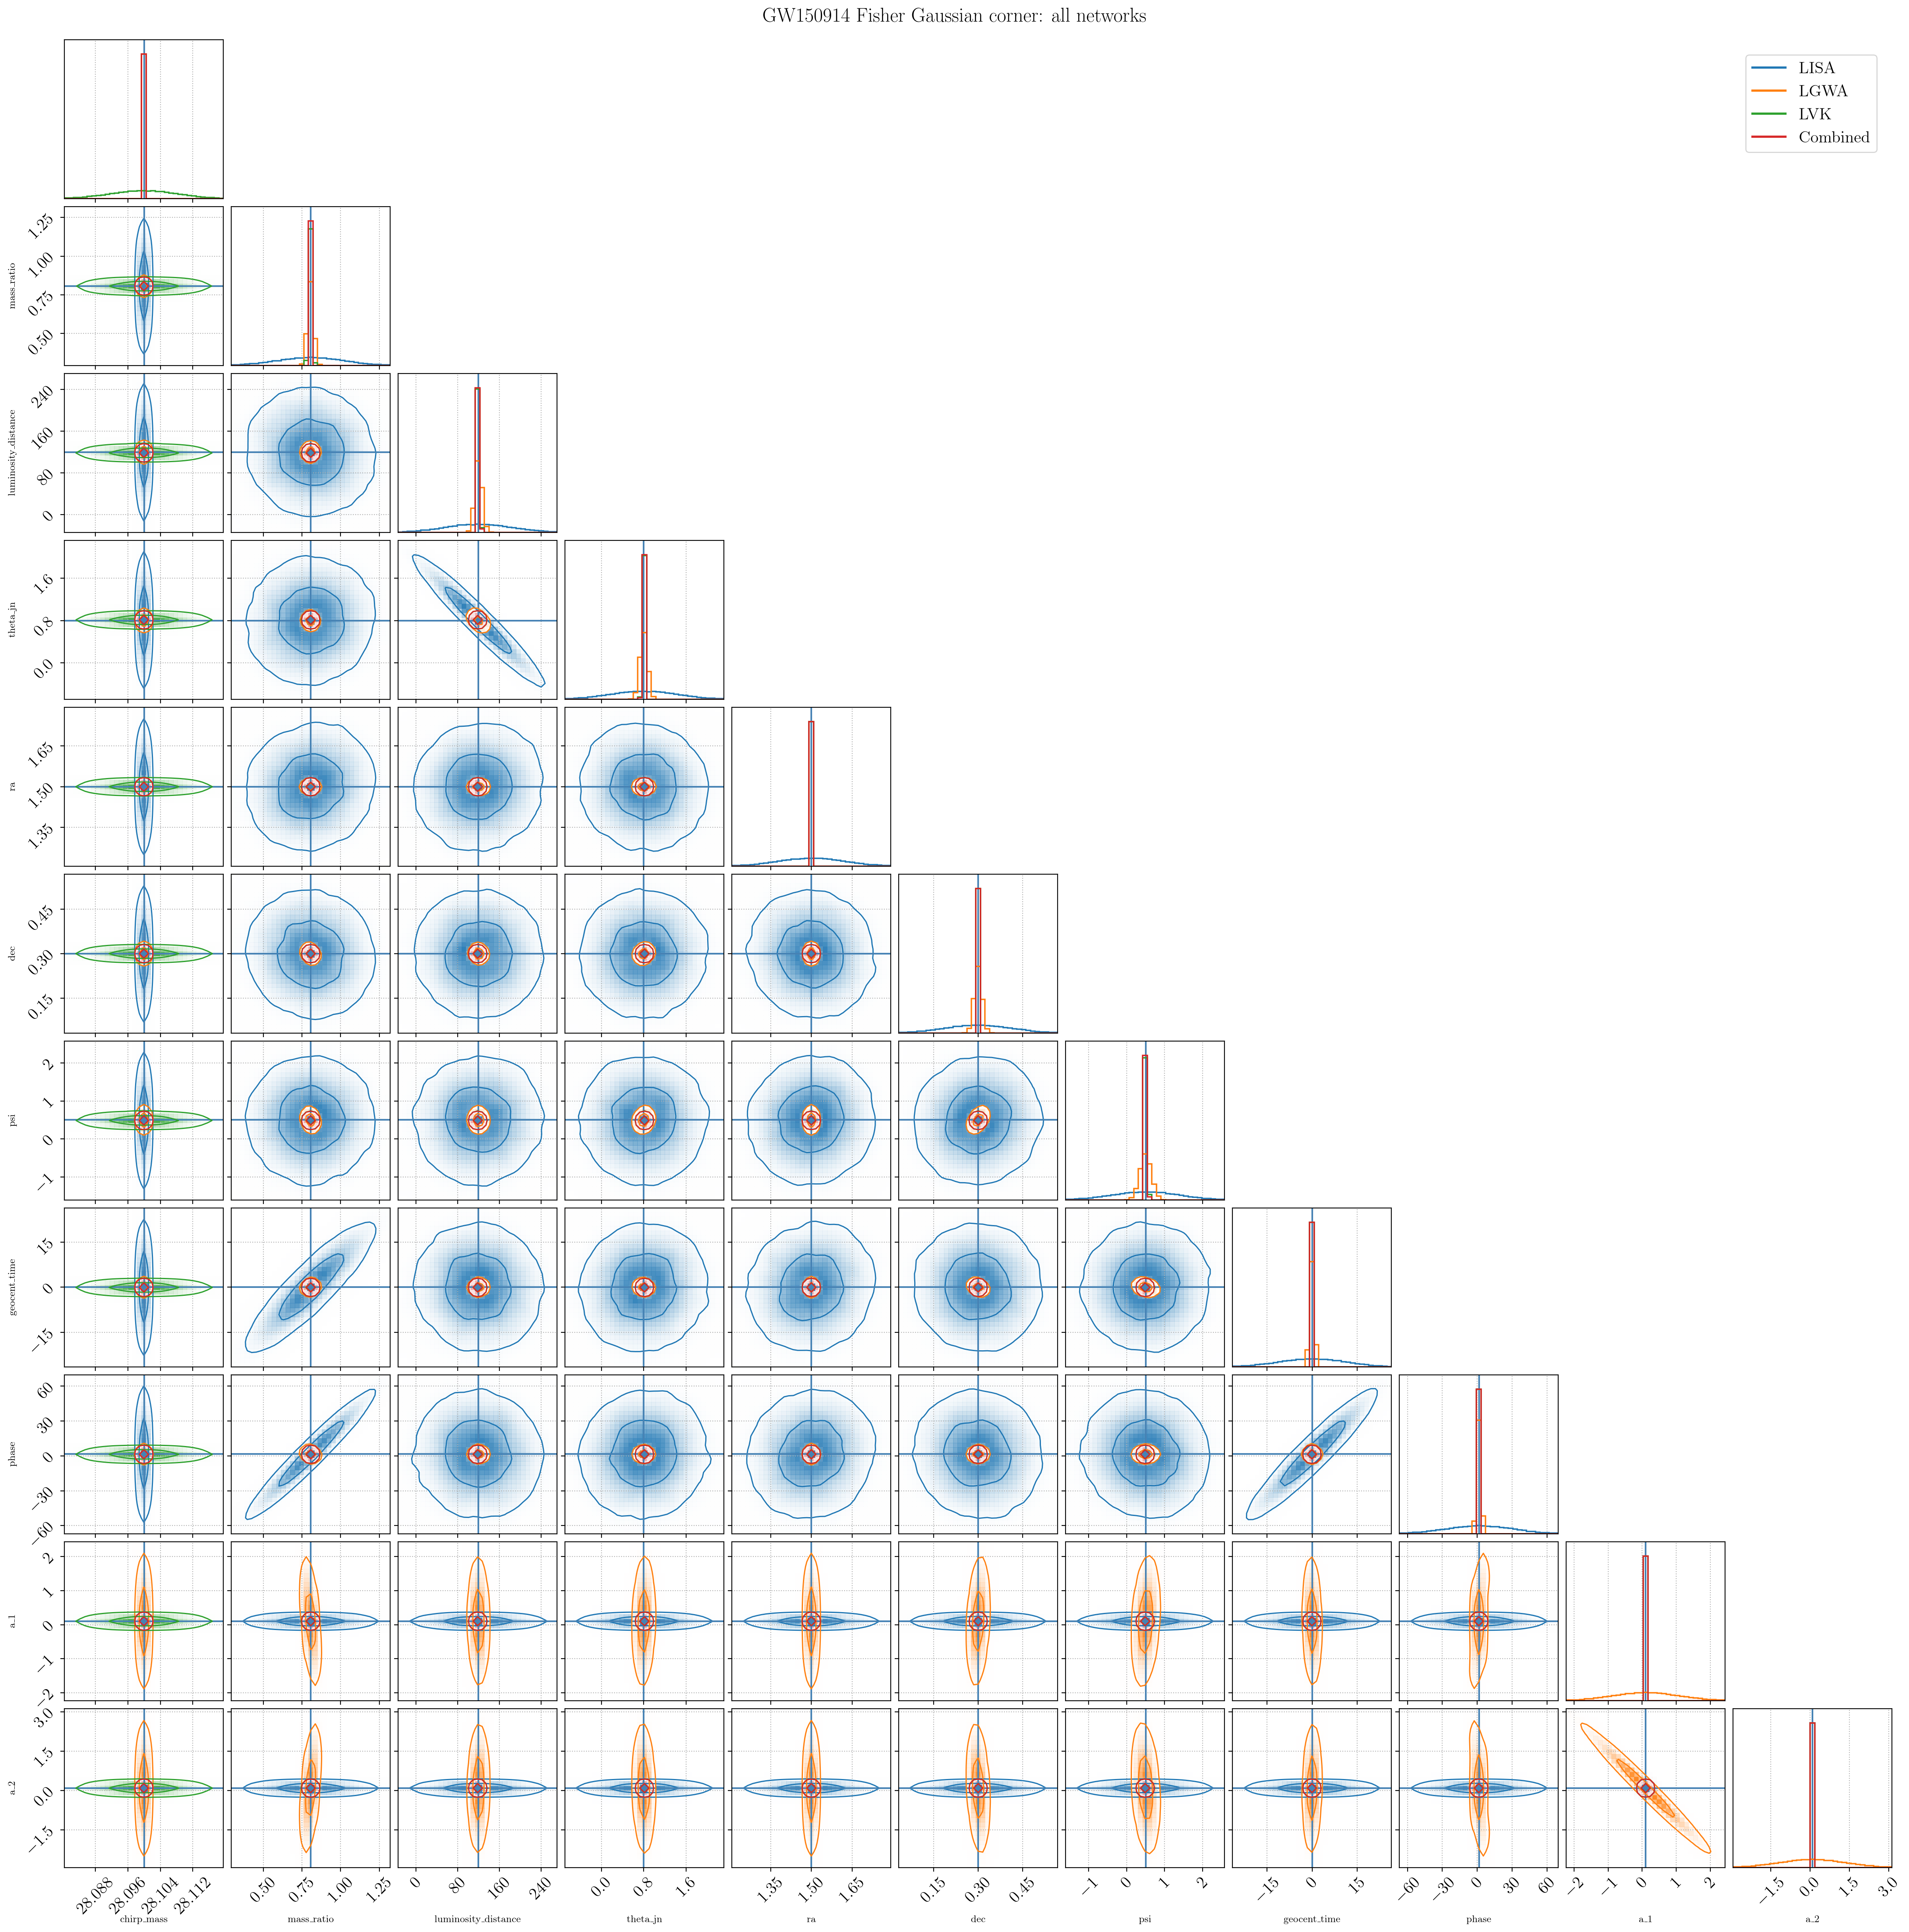

Saved all-network corner plot to /home/ansonchen/multiband_cosmo/plots/gwfish_gw150914_fisher_corner_all_networks.png


PosixPath('/home/ansonchen/multiband_cosmo/plots/gwfish_gw150914_fisher_corner_all_networks.png')

In [8]:
def regularized_covariance_for_sampling(covariance):
    covariance = 0.5 * (covariance + covariance.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    floor = max(np.max(np.abs(eigenvalues)) * 1e-12, 1e-30)
    eigenvalues = np.clip(eigenvalues, floor, None)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T


def sample_fisher_gaussian(mean, covariance, nsamples=50000, seed=1234):
    rng = np.random.default_rng(seed)
    sample_covariance = regularized_covariance_for_sampling(covariance)
    return rng.multivariate_normal(mean, sample_covariance, size=nsamples)


corner_samples = {
    name: sample_fisher_gaussian(fisher_mean, result["covariance"], seed=1234 + index)
    for index, (name, result) in enumerate(fisher_results.items())
}

for network_name, samples in corner_samples.items():
    figure = corner.corner(
        samples,
        labels=FISHER_PARAMETERS,
        truths=fisher_mean,
        show_titles=True,
        title_fmt=".3g",
        quantiles=[0.16, 0.5, 0.84],
        title_kwargs={"fontsize": 9},
        label_kwargs={"fontsize": 9},
    )
    figure.suptitle(f"GW150914 Fisher Gaussian corner: {network_name}", y=1.0)
    output_path = OUTDIR / f"gwfish_gw150914_fisher_corner_{network_name.lower()}.png"
    figure.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(figure)
    print(f"Saved {network_name} corner plot to {output_path}")

combined_corner_output_path = OUTDIR / "gwfish_gw150914_fisher_corner_combined.png"
combined_corner_output_path

# Overlay all network Fisher Gaussian posteriors in one corner plot.
network_colors = {
    "LISA": "tab:blue",
    "LGWA": "tab:orange",
    "LVK": "tab:green",
    "Combined": "tab:red",
}

all_samples = np.vstack([corner_samples[name] for name in FISHER_NETWORKS])
corner_ranges = []
for parameter_index, truth in enumerate(fisher_mean):
    lo, hi = np.quantile(all_samples[:, parameter_index], [0.005, 0.995])
    lo = min(lo, truth)
    hi = max(hi, truth)
    pad = 0.08 * (hi - lo) if hi > lo else 1.0
    corner_ranges.append((lo - pad, hi + pad))

fig_all = None
for network_name in FISHER_NETWORKS:
    fig_all = corner.corner(
        corner_samples[network_name],
        fig=fig_all,
        labels=FISHER_PARAMETERS,
        truths=fisher_mean if fig_all is None else None,
        color=network_colors[network_name],
        range=corner_ranges,
        bins=35,
        smooth=1.0,
        plot_datapoints=False,
        fill_contours=False,
        levels=(0.393, 0.865),
        show_titles=False,
        label_kwargs={"fontsize": 9},
        hist_kwargs={"density": True, "histtype": "step", "linewidth": 1.3},
        contour_kwargs={"linewidths": 1.1},
    )

legend_handles = [
    plt.Line2D([0], [0], color=color, lw=2, label=name)
    for name, color in network_colors.items()
]
fig_all.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98))
fig_all.suptitle("GW150914 Fisher Gaussian corner: all networks", y=1.0)
all_networks_corner_output_path = OUTDIR / "gwfish_gw150914_fisher_corner_all_networks.png"
fig_all.savefig(all_networks_corner_output_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig_all)
print(f"Saved all-network corner plot to {all_networks_corner_output_path}")
all_networks_corner_output_path

## Optional: inspect detector PSD sources

In [9]:
print("GWFish root:", GWFISH_ROOT)
print("LISA is loaded from code/test_notebook_functions.py.")
print("LGWA is loaded through detection.Detector(...).")
print("GWFish LIGO PSD file:", PSD_DIR / "LIGO_O5_psd.txt")
print("Virgo design PSD file:", PSD_DIR / "Virgo_O5_psd.txt")
print("KAGRA design PSD file:", PSD_DIR / "kagra_128Mpc_psd.txt")

GWFish root: /home/ansonchen/multiband_cosmo/.venv/lib/python3.12/site-packages/GWFish
LISA is loaded from code/test_notebook_functions.py.
LGWA is loaded through detection.Detector(...).
GWFish LIGO PSD file: /home/ansonchen/multiband_cosmo/.venv/lib/python3.12/site-packages/GWFish/detector_psd/LIGO_O5_psd.txt
Virgo design PSD file: /home/ansonchen/multiband_cosmo/.venv/lib/python3.12/site-packages/GWFish/detector_psd/Virgo_O5_psd.txt
KAGRA design PSD file: /home/ansonchen/multiband_cosmo/.venv/lib/python3.12/site-packages/GWFish/detector_psd/kagra_128Mpc_psd.txt
